# Plug-and-play in silico ChIP

In [1]:
# Input:
# RNA SCE at choosen resolution
# ATAC SCE at choosen resolution
# Both need to contain lognormalised counts
# Both need to be matched & in the right order

In [14]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
    library(Seurat)
})
source('utils.R')

In [1]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip"

In [76]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## NMP trajectory
#io$RNA_sce = file.path(io$basedir, '/results/rna/metacells/trajectories/nmp/SingleCellExperiment_metacells.rds')
#io$ATAC_sce = file.path(io$basedir, '/results/atac/archR/metacells/trajectories/nmp/PeakMatrix/PeakMatrix_summarized_experiment_metacells.rds')

## blood trajectory
# io$outdir <- file.path(io$basedir,"results/rna_atac/gene_regulatory_networks/metacells/trajectories/blood")
# io$ATAC_sce = file.path(io$outdir,sprintf("PeakMatrix_summarized_experiment_metacells.rds"))
# io$RNA_sce = file.path(io$outdir,"SingleCellExperiment_metacells.rds")

## All celltypes
#io$RNA_sce = file.path(io$basedir, '/results/rna/metacells/all_cells/SingleCellExperiment_metacells.rds')
#io$ATAC_sce = file.path(io$basedir, '/results/atac/archR/metacells/all_cells/PeakMatrix/PeakMatrix_summarized_experiment_metacells.rds')

## All celltype pseudobulk
# io$RNA_sce = file.path(io$basedir, '/results/rna/pseudobulk/celltype/SingleCellExperiment_pseudobulk.rds')
# io$ATAC_sce = file.path(io$basedir, '/results/atac/archR/pseudobulk/celltype/PeakMatrix/pseudobulk_PeakMatrix_summarized_experiment.rds')

## Single-cell
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$ATAC_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")

#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")


In [77]:
#######################
## Load RNA and ATAC 
#######################

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Make sure that samples are consistent
samples <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of metacells: %s",length(samples)))
# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce, 'logcounts') = assay(atac.sce, 'counts') # Try with TF-IDF normalisation
#assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1) # not possible for single-cell data due to massive file size

[1] "Number of metacells: 61886"


In [78]:
rna.sce = logNormCounts(rna.sce)

In [79]:
# RNA dimreduction

decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=4000) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 40, ntop=4000)

In [80]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 1.5)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

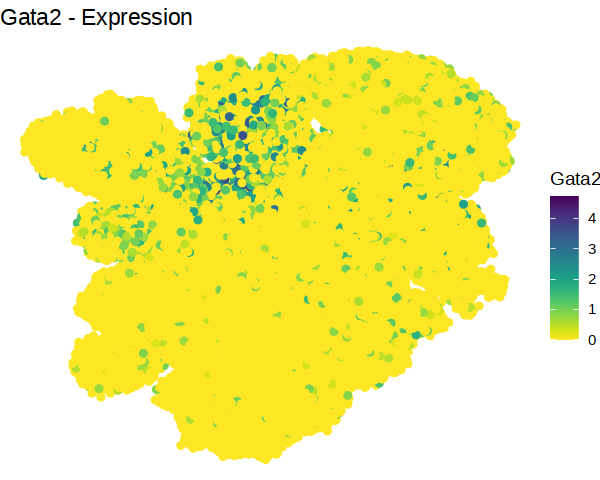

In [81]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Gata2'
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

In [82]:
pca <- reducedDim(sce_filt,"PCA")

In [83]:
counts = matrix(ncol=length(colnames(rna.sce)), nrow=1)
colnames(counts) = colnames(rna.sce)
rownames(counts) = 'x'
seurat = CreateSeuratObject(counts)                
seurat[["pca"]] <- CreateDimReducObject(embeddings = pca, key = "PC_", assay = DefaultAssay(seurat))

In [84]:
# Ultra high clustering resolution instead of metacells
seurat <- FindNeighbors(seurat, dims = 1:40)
seurat <- FindClusters(seurat, resolution = 50)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 61886
Number of edges: 2054815

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6289
Number of communities: 471
Elapsed time: 12 seconds


In [91]:
library(future)
plan("multisession", workers = 24)

In [94]:
seurat <- FindClusters(seurat, resolution = 200)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 61886
Number of edges: 2054815

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.4054
Number of communities: 1346
Elapsed time: 13 seconds


8 singletons identified. 1338 final clusters.

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


In [95]:
clusters = as.data.table(seurat@meta.data, keep.rownames=T) %>% .[,c('rn', 'seurat_clusters')] %>% setnames(c('cell', 'cluster'))

In [97]:
length(unique(clusters$cluster))

[1] 1338

In [98]:
summary(colnames(rna.sce) == clusters$cell)

   Mode    TRUE 
logical   61886 

In [99]:
library(BiocParallel)
BPPARAM = MulticoreParam(detectCores())

In [100]:
rna.pb = aggregateAcrossCells(rna.sce, id=clusters$cluster, BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(atac.sce, id=clusters$cluster, BPPARAM = BPPARAM)

In [101]:
rna.sce_old = rna.sce
atac.sce_old = atac.sce

rna.sce = rna.pb
atac.sce = atac.pb

In [102]:
assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1) 
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)

In [103]:
# RNA dimreduction

decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2000) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 20, ntop=2000)

In [104]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 1.5)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

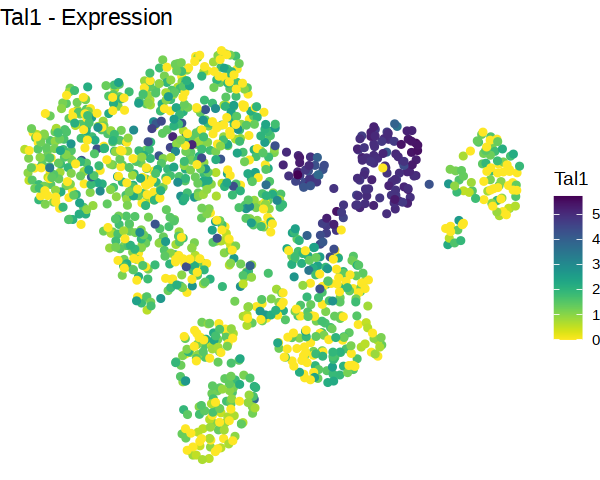

In [105]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Tal1'
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

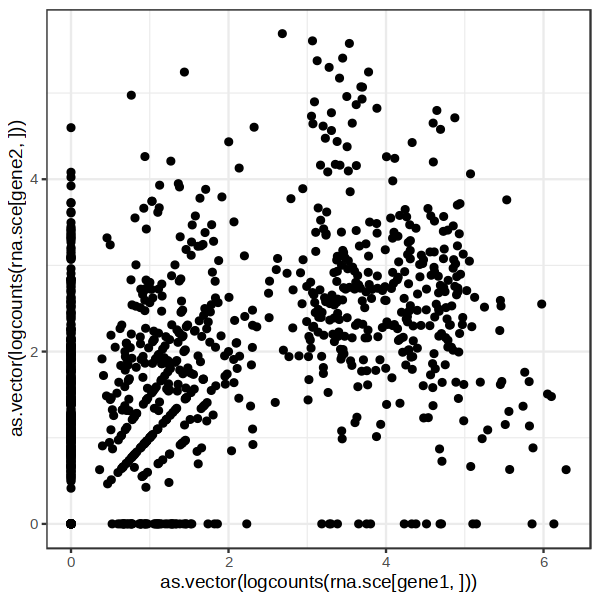

In [106]:
gene1 = 'Eomes'
gene2 = 'Gata2'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(data.table(dummy = rep('a', length(colnames(rna.sce)))), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    theme_bw()

In [107]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [108]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 192251 871 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(871): TFAP2B_1 TFAP2D_2 ... TBX22_870 TBXT
colData names(1): name

DataFrame with 871 rows and 1 column
                 name
          <character>
TFAP2B_1       TFAP2B
TFAP2D_2       TFAP2D
TFAP2C_3       TFAP2C
TFAP2E_4       TFAP2E
TFAP2A_5       TFAP2A
...               ...
SMAD9_867       SMAD9
SOX6_868         SOX6
TBX18_869       TBX18
TBX22_870       TBX22
TBXT             Tbxt

In [121]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = colData(motifmatcher.se)$name,  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = c("T_789"),
                          cores=1) # got an error this time with more cores
b = Sys.time()
b-a

Removing 0 TFs that have duplicated gene-motif pairs:
Correlate TF-expr & Region-accessibility

Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”
Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”
Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”
Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”
Warning message in `[.data.table`(., , `:=`(peak, rownames(atac.sce))):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


Time difference of 27.96103 mins

In [122]:
tf2peak_cor.se

class: SummarizedExperiment 
dim: 192251 725 
metadata(0):
assays(2): cor pvalue
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(725): SOX17 MYBL1 ... YY2 SRY
colData names(0):

In [123]:
gata1 = assay(tf2peak_cor.se[, 'GATA1'], 'cor')

In [126]:
as.data.table(as.matrix(gata1), keep.rownames=T) %>% .[order(-GATA1)] %>% head()

rn,GATA1
<chr>,<dbl>
chr7:103876993-103877593,0.683
chr3:103799409-103800009,0.678
chr12:12487948-12488548,0.674
chr6:87775758-87776358,0.673
chr3:60819512-60820112,0.672
chr10:96204070-96204670,0.666


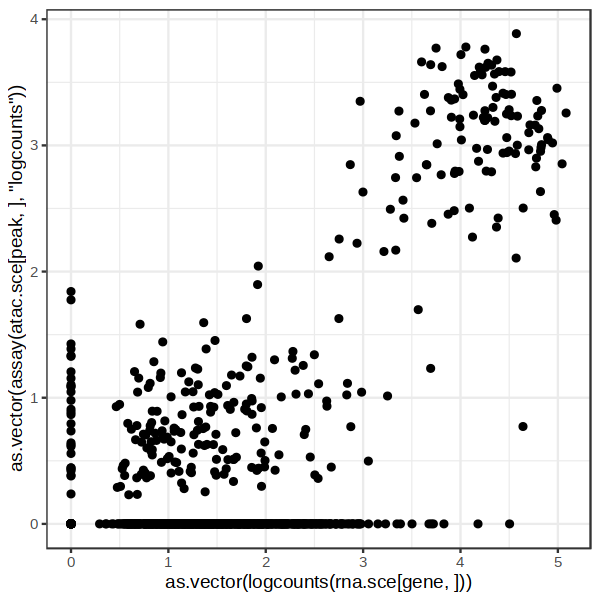

In [127]:
gene = 'Gata1'
peak = 'chr7:103876993-103877593'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(data.table(dummy = rep('a', length(colnames(rna.sce)))), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak,], 'logcounts')))) + 
                    geom_point() + 
                    theme_bw()

In [128]:
summary(duplicated(colnames(tf2peak_cor.se)))

   Mode   FALSE 
logical     725 

In [134]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = 1)
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 725"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 16.88538 mins

In [139]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 192251 721 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(721): AHR AHRR ... ZKSCAN4 ZSCAN10
colData names(1): name

In [140]:
source('utils.R')

In [141]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()
# load background peak set
bgdPeaks.se <- readRDS(io$background_peaks)

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 18769583"
[1] "Number of matches after filtering negative TF binding values: 11755939"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 11755939"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 344917"
280 TFs removed because they don't have enough binding sites: AHR AHRR ARID5A ARNT ARNTL ASCL1 ATF1 ATF2 ATF4 ATF5 ATF7 ATOH1 ATOH7 BACH1 BARHL1 BARHL2 BARX1 BARX2 BATF BATF3 BCL6 BCL6B BHLHA15 BHLHE22 BHLHE23 BHLHE40 BHLHE41 BSX CDC5L CEBPA CEBPD CEBPE CEBPG CENPB CIC CPEB1 CREB3L4 CREB5 CREM CRX CTCFL CXXC1 DBP DLX1 DLX4 DMRT1 DMRT3 DMRTC2 E2F1 E2F2 E2F3 E2F4 E2F6 E2F7 E2F8 E4F1 EGR2 EGR3 EGR4 EHF ELK1 ELK4 EMX1 ESR1 ETV3 EVX2 FERD3L FEV FIGLA FOXB2 FOXD4 FOXE1 FOXE3 FOXH1 FOXI1 FOXK1 FOXM1 FOXO6 FOXP3 FOXS1 GABPA GCM1 GCM2 GFI1 GLIS2 GMEB1 GMEB2 GRHL1 GSC2 GSX1 GSX2 HBP1 HES2 HES7 HESX1 HEY1 HEYL HIC1 HIF1A HINFP HIVEP3 HLF HMGA1 HMX1 HMX2 HMX3 HOMEZ HOXB13 HOXC12 HOXC13

Time difference of 3.689302 mins

In [144]:
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())

[1] "Number of matches before filtering based on minimum ChIP-seq score: 18769583"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 18769583"
Running ChromVAR-ChIP-seq (ArchR implementation) 


In [145]:
chromvar_deviations.se

class: SummarizedExperiment 
dim: 441 1338 
metadata(0):
assays(2): deviations z
rownames(441): AIRE ALX1 ... ZKSCAN1 ZSCAN10
rowData names(2): fractionMatches fractionBackgroundOverlap
colnames(1338): 0 1 ... 1336 1337
colData names(0):

In [146]:
chromvar_deviations_original.se

class: SummarizedExperiment 
dim: 721 1338 
metadata(0):
assays(2): deviations z
rownames(721): AHR AHRR ... ZKSCAN4 ZSCAN10
rowData names(2): fractionMatches fractionBackgroundOverlap
colnames(1338): 0 1 ... 1336 1337
colData names(0):

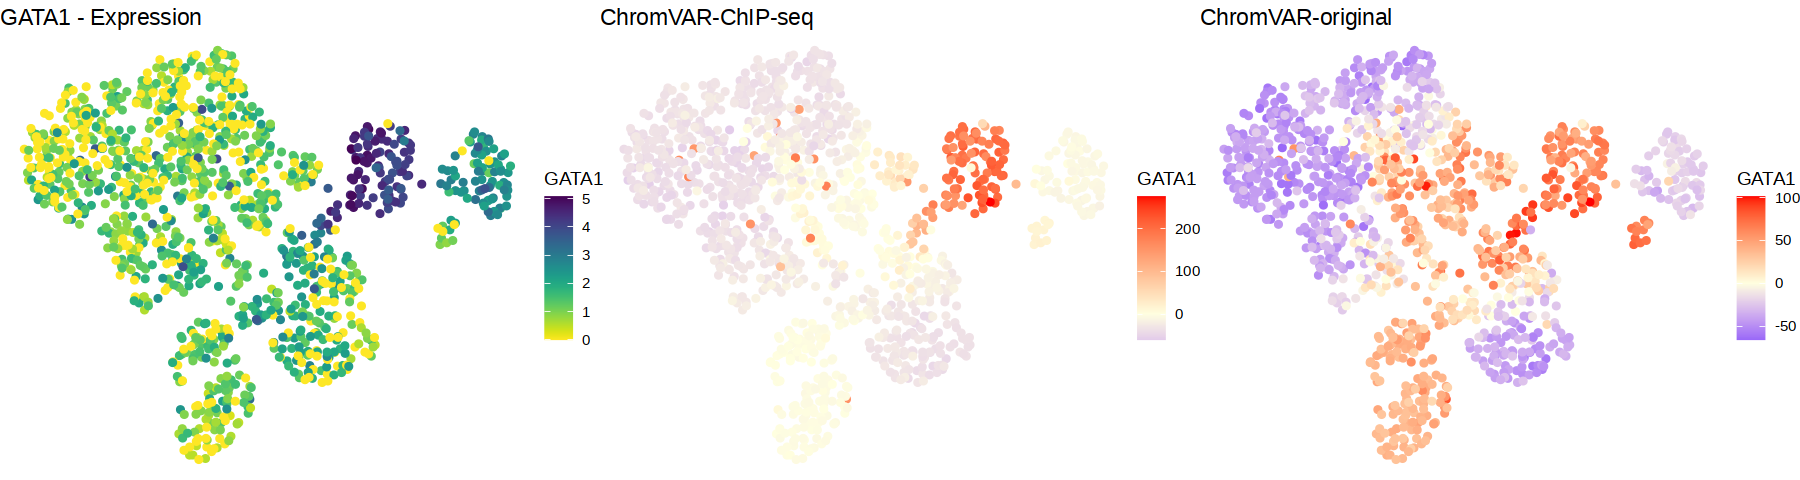

In [147]:
TF = 'GATA1'

p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
    ggtitle(paste0(TF, ' - Expression')) + 
    theme_void()

p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-ChIP-seq') + 
    theme_void()

p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-original') + 
    theme_void()
options(repr.plot.width=15, repr.plot.height=4)
ggarrange(p1, p2, p3, nrow = 1)

In [ ]:
TF_correlations = mclapply(unique(rownames(chromvar_deviations.se)), function(x){
      corr_output <- psych::corr.test(
        x = as.vector(assay(chromvar_deviations.se[x,], 'z')), 
        y = as.vector(assay(rna.sce[str_to_title(x),], 'logcounts')), 
        ci = FALSE,
        method = 'pearson'
      )
    
    tmp = data.table(tf = x,
                     cor = round(corr_output$r,3),
                     pval = round(corr_output$p,10))
    return(tmp)
}, mc.cores = detectCores()) %>% rbindlist() %>%
    .[order(-cor)] %>%
    .[,rank:=.I]

In [ ]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(TF_correlations, aes(rank, cor)) + 
    geom_point(col='gray80') +
    ggrepel::geom_text_repel(data = head(TF_correlations, 10), aes(label=tf)) + 
    ggtitle('TF-ChromVAR correlations') + 
    ylab('Correlation score') + 
    theme_bw()

In [ ]:
######################################
## link TF2genes virtual chip
######################################
# peak2gene (also possible to find them in the function, need to supply gene metadata with gene locations(e.g. from biomaRt))
peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz") 

## Load peak2gene linkages using only genomic distance
peak2gene.dt <- fread(peak2gene)
head(peak2gene.dt)
summary(peak2gene.dt$dist)

a = Sys.time()
TF2Gene_links = TF2Gene(rna.sce = rna.sce, 
                   motifmatcher_chip.se = motifmatcher_chip.se,
                   peak2gene.dt = peak2gene.dt,
                   min_chip_score = 0.15,
                   distance = 1.5e5, # Can not be higher than the max distance in peak2gene.dt, unless recalculated from gene metadata file
                   cores = detectCores())
b = Sys.time()
b-a
head(TF2Gene_links)

In [ ]:
# Inspect silico ChIP-scores & TF-gene beta values
options(repr.plot.width=20, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')
p2 = gghistogram(TF2Gene_links$beta[abs(TF2Gene_links$beta)>0.05 & abs(TF2Gene_links$beta)<quantile(abs(TF2Gene_links$beta), 0.99)], bins=100) + ggtitle('TF-gene beta values')
ggarrange(p1, p2)

In [ ]:
suppressMessages(library(GGally))
suppressMessages(library(igraph))
#suppressMessages(library(network))
#suppressMessages(library(sna))
suppressMessages(library(ggraph))
suppressMessages(library(igraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

In [ ]:
#################
## Build GRN
#################
max_distance = 1.5e5
min_chip_score = 0.1
min_beta = 0.1
min_pvalue = 0.1
min_TF_expr = 5 # Min logcounts
TF_filter = NULL #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
TF_TF_only = TRUE
motifmatcher_chip.se = motifmatcher_chip.se
assay = 'VirtualChipScores'
rna.sce = rna.sce
min_targets = 3
cores = detectCores()

In [ ]:
tf2gene_chip.dt <- mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
        virtual_chip.mtx = assay(motifmatcher_chip.se, assay)
        # Select target peaks (note that we only take positive correlations into account)
        target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
        if (length(target_peaks_i)>=1) {
            tmp <- data.table(
              tf = i,
              peak = target_peaks_i,
              chip_score = virtual_chip.mtx[target_peaks_i,i]
            ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
            return(tmp)
            }
        }, mc.cores=cores) %>% rbindlist %>%
        .[,gene:=toupper(gene)] %>%
        .[chip_score >= min_chip_score & dist <= max_distance]

options(repr.plot.width=6, repr.plot.height=3)
max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                      max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

GRN_coef.dt <- TF2Gene_links %>% 
  .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
  .[,gene:=toupper(gene)] %>%
  .[tf %in% TF_keep]
if(!is.null(TF_filter)){
    GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
}
if(TF_TF_only){
    GRN_coef.dt = GRN_coef.dt[gene %in% tf]
}

GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
    .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
    unique(by=c('tf', 'gene')) %>%
    .[,c('tf', 'gene', 'beta')] %>% 
    .[,N := .N, by='tf'] %>%
    .[N >= min_targets] 

if(TF_TF_only){
    GRN.dt = GRN.dt[gene %in% tf]
}

In [ ]:
# Create node and edge data.frames
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

In [ ]:
igraph.tbl

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'kk') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +
  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

# ChromVAR on single-cell data

In [ ]:
# io$ATAC_sce = file.path(io$outdir,sprintf("PeakMatrix_summarized_experiment_metacells.rds"))
# io$RNA_sce = file.path(io$outdir,"SingleCellExperiment_metacells.rds")

In [25]:
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$ATAC_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")

In [26]:
#######################
## Load RNA and ATAC 
#######################

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Make sure that samples are consistent
samples <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of metacells: %s",length(samples)))
# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce, 'logcounts') = assay(atac.sce, 'counts') # Try with TF-IDF normalisation
#assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1) # not possible for single-cell data due to massive file size

[1] "Number of metacells: 61886"


In [27]:
rna.sce
atac.sce

class: SingleCellExperiment 
dim: 32285 61886 
metadata(0):
assays(1): counts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(61886): E7.5_rep1#AAACAGCCAAACCCTA-1
  E7.5_rep1#AAACAGCCATCCTGAA-1 ... E8.5_CRISPR_T_WT#TTTGTTGGTGGCTTCC-1
  E8.5_CRISPR_T_WT#TTTGTTGGTTGGCCGA-1
colData names(10): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

class: RangedSummarizedExperiment 
dim: 192251 61886 
metadata(0):
assays(2): counts logcounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(61886): E7.5_rep1#AAACAGCCAAACCCTA-1
  E7.5_rep1#AAACAGCCATCCTGAA-1 ... E8.5_CRISPR_T_WT#TTTGTTGGTGGCTTCC-1
  E8.5_CRISPR_T_WT#TTTGTTGGTTGGCCGA-1
colData names(35): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [29]:
rna.sce = logNormCounts(rna.sce)

In [30]:
# RNA dimreduction

decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 35, ntop=2500)

In [31]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 1.5)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

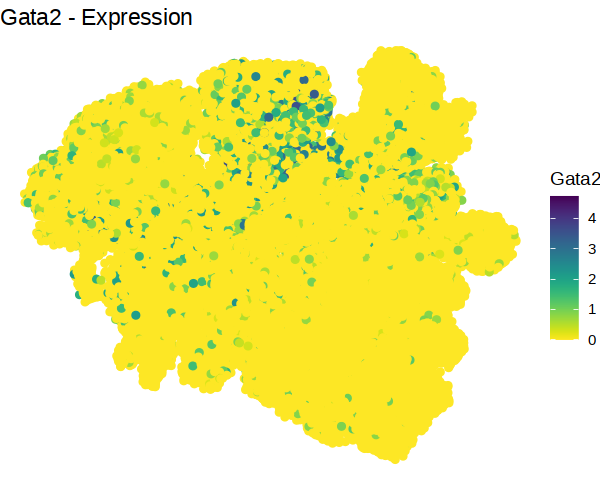

In [32]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Gata2'
ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

In [34]:
atac.sce

class: RangedSummarizedExperiment 
dim: 192251 61886 
metadata(0):
assays(2): counts logcounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(61886): E7.5_rep1#AAACAGCCAAACCCTA-1
  E7.5_rep1#AAACAGCCATCCTGAA-1 ... E8.5_CRISPR_T_WT#TTTGTTGGTGGCTTCC-1
  E8.5_CRISPR_T_WT#TTTGTTGGTTGGCCGA-1
colData names(35): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [35]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 192251 732 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(732): AHR AHRR ... ZKSCAN4 ZSCAN10
colData names(1): name

In [36]:
atac.sce = atac.sce
motifmatcher_chip.se = motifmatcher_chip.se
assay = 'VirtualChipScores'
background = bgdPeaks.se
genome = NULL # Only needed if background = NULL
positive_only = TRUE
min_chip_score = 0.15
min_number_peaks = 50
TFs_filt = NULL
test = FALSE
method = 'ArchR' # Option 'ArchR' or 'ChromVAR'
cores = detectCores()

In [37]:
    if(method == 'ChromVAR'){
        background = NULL
        cat('Background peaks recalculated for method = ChromVAR \n')
        if(is.null(genome)){
            cat('Please provide genome \n')
        }
    }
    
    if (positive_only){
      print(sprintf("Number of matches before filtering negative TF binding values: %d",sum(assay(motifmatcher_chip.se,"motifMatches"))))
      assay(motifmatcher_chip.se,"motifMatches")[assay(motifmatcher_chip.se, assay)<0] <- F
      print(sprintf("Number of matches after filtering negative TF binding values: %d",sum(assay(motifmatcher_chip.se,"motifMatches"))))
    }

    print(sprintf("Number of matches before filtering based on minimum ChIP-seq score: %d",sum(assay(motifmatcher_chip.se,"motifMatches"))))
    assay(motifmatcher_chip.se,"motifMatches")[abs(assay(motifmatcher_chip.se, assay))<=min_chip_score] <- F
    print(sprintf("Number of matches after filtering based on minimum ChIP-seq score: %d",sum(assay(motifmatcher_chip.se,"motifMatches"))))

    assays(motifmatcher_chip.se) <- assays(motifmatcher_chip.se)["motifMatches"]
    
    
    ## Filter TFs 
    # Filter TFs with too few peaks
    TFs <- which(colSums(assay(motifmatcher_chip.se,"motifMatches")) >= min_number_peaks) %>% names
    TFs.removed <- which(colSums(assay(motifmatcher_chip.se,"motifMatches")) < min_number_peaks) %>% names
    
    # Subset to TFs of interest
    if(!is.null(TFs_filt)){ 
        TFs = TFs[TFs %in% TFs_filt]
    }
    if(length(TFs.removed>0)){
        cat(sprintf("%s TFs removed because they don't have enough binding sites: %s \n", length(TFs.removed), paste(TFs.removed, collapse=" ")))
    }
    
    if(test){
      TFs <- c("FOXA2","MIXL1","GATA1","EOMES","BCL11B","DLX2","FOXC1")
    }
    
    motifmatcher_chip.se <- motifmatcher_chip.se[,TFs]    
    stopifnot(rownames(atac.sce)==rownames(motifmatcher.se))  
    
    if(!is.null(background)){
        ## Load background peaks
        bgdPeaks.se = background
        tmp <- rowRanges(bgdPeaks.se)
        rownames(bgdPeaks.se) <- sprintf("%s:%s-%s",seqnames(tmp), start(tmp), end(tmp))
        bgdPeaks.se <- bgdPeaks.se[rownames(atac.sce),] # subset to same peaks as in filtered atac.sce
        bg = assay(bgdPeaks.se)
    } else{
        ## Determine background peaks
        if(is.null(genome)){
            cat('Please provide genome \n')
            stop()
        }
    
        ## Filter non-accessible peaks
        peaks = rowSums(assay(atac.sce, 'counts'))>0
        atac.sce = atac.sce[peaks,]
        motifmatcher_chip.se = motifmatcher_chip.se[peaks,]   
        
        ## Calculate background peaks
        cat('Calculating background peaks \n')
        peaks = rownames(atac.sce_filt)
        library(GenomicRanges)
        gr <- GRanges(
            seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
            ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
                             end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
            strand = Rle(rep('*', length(peaks))))
        atac.rse = as(atac.sce_filt, 'RangedSummarizedExperiment')
        atac.rse@rowRanges = gr
        
        ## Adding background peaks
        atac.rse <- addGCBias(atac.rse, genome = genome)
        bg <- getBackgroundPeaks(object = atac.rse)
    }

[1] "Number of matches before filtering negative TF binding values: 18945532"
[1] "Number of matches after filtering negative TF binding values: 10714289"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 10714289"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 1409335"
9 TFs removed because they don't have enough binding sites: E2F3 HOXC12 PAX1 POU1F1 SIM2 TBX1 TBX18 TBX22 TOPORS 


In [38]:
rowData(atac.sce)

DataFrame with 192251 rows and 1 column
                             idx
                         <array>
chr1:3035602-3036202           1
chr1:3062653-3063253           2
chr1:3072313-3072913           3
chr1:3191496-3192096           4
chr1:3340575-3341175           5
...                          ...
chrX:169902806-169903406    3284
chrX:169905921-169906521    3285
chrX:169915616-169916216    3286
chrX:169925487-169926087    3287
chrX:169937064-169937664    3288

In [39]:


    
    ## ChromVAR ChIP-seq
    if(method == 'ArchR'){
        cat('Running ChromVAR-ChIP-seq (ArchR implementation) \n')
        
        featureDF <- data.frame(
          rowSums = rowSums(assay(atac.sce))#,
    #      start = rowData(atac.sce)$start,
    #      end = rowData(atac.sce)$end
        )

        # Compute deviations
        chromvar_deviations.se <- ArchR:::.customDeviations(
          countsMatrix = assay(atac.sce),
          annotationsMatrix = as(assay(motifmatcher_chip.se),"dgCMatrix"),
          backgroudPeaks = bg,
          expectation = featureDF$rowSums/sum(featureDF$rowSums),
          prefix = "",
          out = c("deviations", "z"),
          threads = cores,
          verbose = TRUE
        )
    } else if(method == 'ChromVAR'){
        cat('Running ChromVAR-ChIP-seq (ChromVAR implementation) \n')
        library(BiocParallel)
        #stop()
        register(MulticoreParam(cores))
        assayNames(atac.sce) <- "counts"

        # Compute deviations
        chromvar_deviations_chromvar.se <- chromVAR::computeDeviations(
          object = atac.sce,
          annotations = assay(motifmatcher_chip.se),
          background_peaks = bg
        )
        
    } else{
        print('Choose either option "ArchR" or "ChromVAR"')
    }

Running ChromVAR-ChIP-seq (ArchR implementation) 


as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead



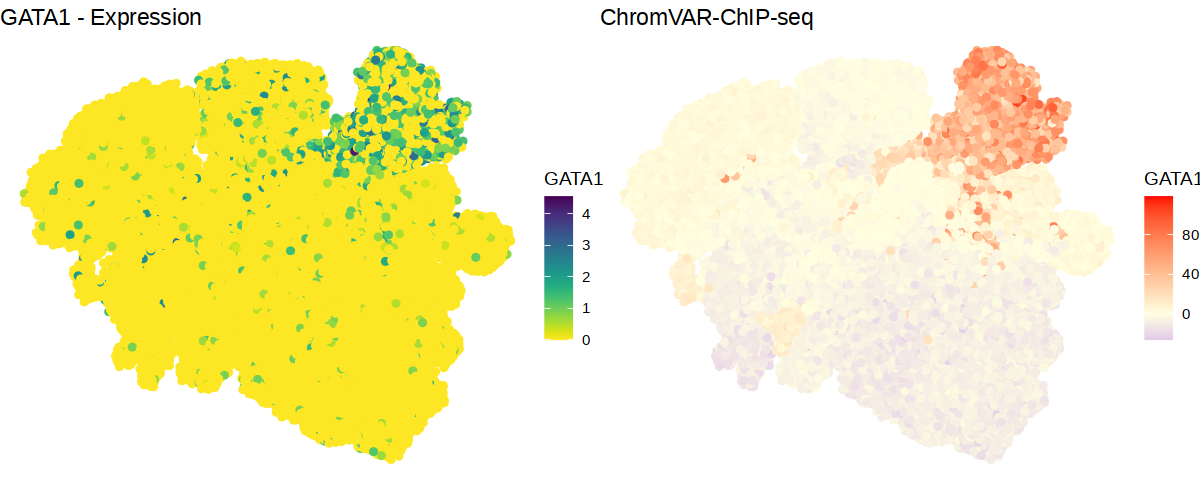

In [42]:
TF = 'GATA1'
p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
    ggtitle(paste0(TF, ' - Expression')) + 
    theme_void()

p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-ChIP-seq') + 
    theme_void()
options(repr.plot.width=10, repr.plot.height=4)
ggarrange(p1, p2, nrow = 1)

In [33]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()
# load background peak set
bgdPeaks.se <- readRDS(io$background_peaks)

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 18945532"
[1] "Number of matches after filtering negative TF binding values: 10714289"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 10714289"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 1409335"
9 TFs removed because they don't have enough binding sites: E2F3 HOXC12 PAX1 POU1F1 SIM2 TBX1 TBX18 TBX22 TOPORS 
Running ChromVAR-ChIP-seq (ArchR implementation) 


ERROR: Error in data.frame(rowSums = rowSums(assay(atac.sce)), start = rowData(atac.sce)$start, : arguments imply differing number of rows: 192251, 0


In [ ]:
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())

In [ ]:
TF = 'GATA1'

p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
    ggtitle(paste0(TF, ' - Expression')) + 
    theme_void()

p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-ChIP-seq') + 
    theme_void()

p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-original') + 
    theme_void()
options(repr.plot.width=15, repr.plot.height=4)
ggarrange(p1, p2, p3, nrow = 1)

In [ ]:
GRN.dt

In [152]:
io$cell2metacell <- file.path(io$outdir, "cell2metacell_assignment.txt.gz")


In [153]:
cell2metacell = fread(io$cell2metacell)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


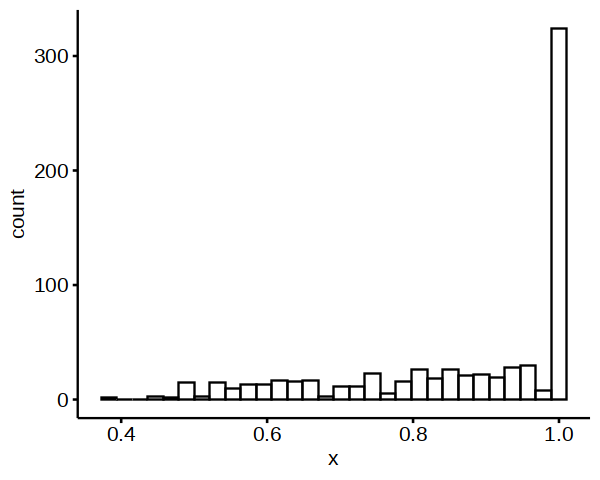

In [156]:
gghistogram(cell2metacell %>% unique(by='metacell') %>% .$celltype_purity)

In [154]:
head(cell2metacell)

cell,metacell,celltype,celltype_purity
<chr>,<chr>,<chr>,<dbl>
E7.5_rep1#AAACAGCCATCCTGAA-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#CTTAGTTTCATCCTCA-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#GCACATTAGTTTGGGT-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep1#TCACTGACAGGCTAAG-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep2#ACACGGACACCTGCTC-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
E7.5_rep2#ATGAGCCGTAAATTGC-1,E7.5_rep1#AAACAGCCATCCTGAA-1,Mixed_mesoderm,0.5454545
